# **1. Data preprocessing**

Dataset info

General Overview
The dataset comprises 7,043 individual customer records from a telecommunications company, providing a comprehensive snapshot of consumer behavior and service usage. Each instance represents a unique customer profile, characterized by 21 distinct features ranging from demographic information to service-specific metrics and billing details. The data serves as a benchmark for binary classification tasks, specifically focused on predicting Customer Churn—the phenomenon where clients terminate their service agreements with the provider.

Data Integrity and Synthetic Missingness While the original dataset from the provided source  is largely complete and consistent, it does not inherently contain a sufficient volume of missing values to conduct a robust comparative analysis of imputation techniques. To address the core research objective of this project—evaluating the impact of data recovery on model performance—a synthetic missingness of 10% has been manually injected into the features. This deliberate modification transforms the "clean" dataset into a challenging environment for data engineering.
Comparative Imputation Framework The primary motivation for introducing these gaps is to create a controlled experimental setup to compare four distinct data recovery strategies.

Dataset Link: https://www.kaggle.com/datasets/cdeotte/s6e3-original-dataset/data

In [51]:
# wczytanie bibliotek
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
# wczytanie danych
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.head(10))

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   
5  9305-CDSKC  Female              0      No         No       8          Yes   
6  1452-KIOVK    Male              0      No        Yes      22          Yes   
7  6713-OKOMC  Female              0      No         No      10           No   
8  7892-POOKP  Female              0     Yes         No      28          Yes   
9  6388-TABGU    Male              0      No        Yes      62          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL        

In [53]:
# usunięcie kolumny z ID klienta - jest ono zawsze unikalne, może przeszkadzać w klasyfikacji
df.drop('customerID', axis=1, inplace=True)
print(df.head(10))

   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   
5  Female              0      No         No       8          Yes   
6    Male              0      No        Yes      22          Yes   
7  Female              0      No         No      10           No   
8  Female              0     Yes         No      28          Yes   
9    Male              0      No        Yes      62          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes

In [54]:
# wgląd w kolumny
print(df.describe())

       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


In [55]:
#sprawdzenie błędów
print("Wrong data per column:")
print((df == -200).sum())

Wrong data per column:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [56]:
# sprawdzenie pustych rekordów
missing_data = df.isna().any().any()
print(f"Is missing data in the dataset: {missing_data}")
print(f"Missing data per column:")
print(df.isna().sum())

Is missing data in the dataset: False
Missing data per column:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [57]:
# sprawdzenie zduplikowanych danych
print(f"Duplicated data:")
print(df.duplicated().sum())

Duplicated data:
22


Creating missing data

We are randomly creating missing data from dataset to compare imputation methods, even for column which depends on values from other colums - to point out how each method will deal with this problem.

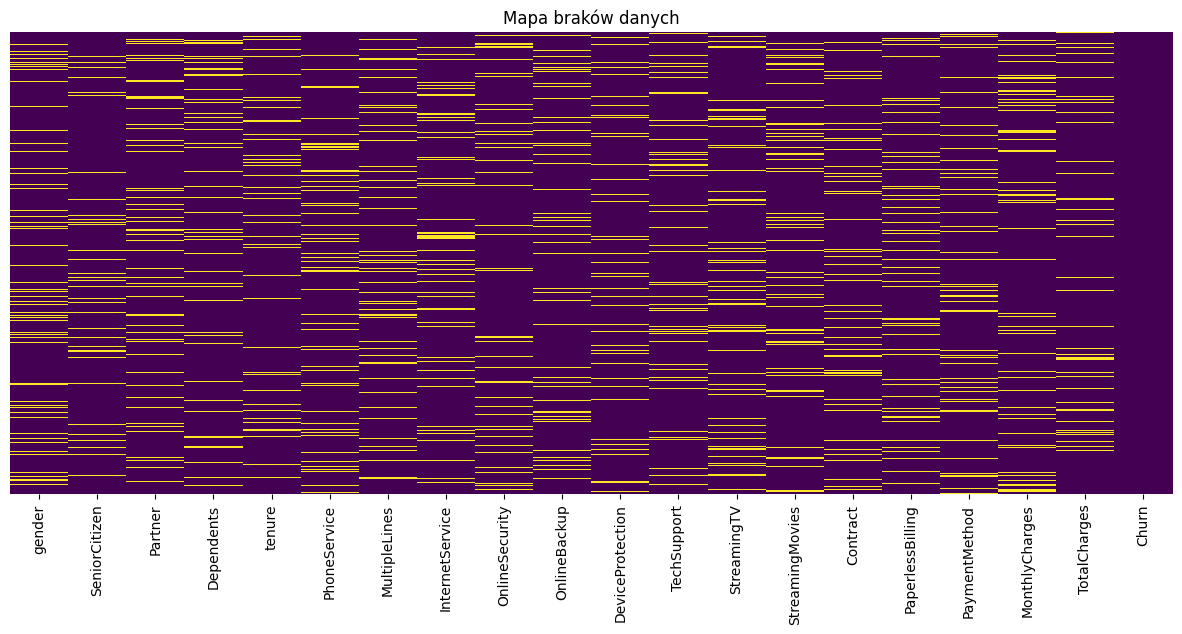

Procent braków w wybranych kolumnach:
gender             10.0
SeniorCitizen      10.0
Partner            10.0
Dependents         10.0
tenure             10.0
PhoneService       10.0
MultipleLines      10.0
InternetService    10.0
OnlineSecurity     10.0
OnlineBackup       10.0
dtype: float64
Weryfikacja braków po modyfikacji:
gender              704
SeniorCitizen       704
Partner             704
Dependents          704
tenure              704
PhoneService        704
MultipleLines       704
InternetService     704
OnlineSecurity      704
OnlineBackup        704
DeviceProtection    704
TechSupport         704
StreamingTV         704
StreamingMovies     704
Contract            704
PaperlessBilling    704
PaymentMethod       704
MonthlyCharges      704
TotalCharges        704
Churn                 0
dtype: int64
Braki w kolumnie Churn: 0


In [58]:
# sztuczne tworzenie braków w danych ze względu na ich kompletność - 10% danych

# ziarno losowości
np.random.seed(8)
# wybór kolumn do utworzenia braków, pomijamy kolumnę churn do klasyfikacji
# wybieramy także kolumny zależne od siebie, głównie po to, aby pokazać różnice pomiędzy metodami imputacji danych
cols_to_corrupt = [col for col in df.columns if col != 'Churn']

# 10% braków w każdej z kolumn
for col in cols_to_corrupt:
    # losowe 10% indeksów dla każdej z kolumn
    n_missing = int(len(df) * 0.1)
    missing_indices = np.random.choice(df.index, n_missing, replace=False)
    df.loc[missing_indices, col] = np.nan

# mapa braków danych
plt.figure(figsize=(15, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Mapa braków danych')
plt.show()

# podsumowanie procentowe i ilościowe brakujących rekordów dla wybranych kolumn
print("Procent braków w wybranych kolumnach:")
print(round((df.isnull().sum() / len(df) * 100), 2).head(10))
print("Weryfikacja braków po modyfikacji:")
print(df.isna().sum())
print(f"Braki w kolumnie Churn: {df['Churn'].isnull().sum()}")


In [59]:
# ponowne sprawdzenie zduplikowanych danych
print(f"Duplicated data:")
print(df.duplicated().sum())

Duplicated data:
0


In [89]:
# pobranie typów danych
df.info()

# enkodowanie nastąpi po imputacji danych, narazie niezbedne jest jedynie zmiana typu danych dla kolumny TotalChanges na numeryczne
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df[['TotalCharges']].dtypes)

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            6339 non-null   str    
 1   SeniorCitizen     6339 non-null   Int64  
 2   Partner           6339 non-null   str    
 3   Dependents        6339 non-null   str    
 4   tenure            6339 non-null   float64
 5   PhoneService      6339 non-null   str    
 6   MultipleLines     6339 non-null   str    
 7   InternetService   6339 non-null   str    
 8   OnlineSecurity    6339 non-null   str    
 9   OnlineBackup      6339 non-null   str    
 10  DeviceProtection  6339 non-null   str    
 11  TechSupport       6339 non-null   str    
 12  StreamingTV       6339 non-null   str    
 13  StreamingMovies   6339 non-null   str    
 14  Contract          6339 non-null   str    
 15  PaperlessBilling  6339 non-null   str    
 16  PaymentMethod     6339 non-null   str    
 17  Monthl

The initial dataset was intentionally modified by introducing 10% missing values (NaN) across all features (excluding the target variable Churn). To address this, we implemented four distinct imputation strategies to evaluate their impact on model performance:
- Simple Statistical Imputation (Fills missing numerical values with the Median, categorical values with the Mode (the most frequent occurrence))
- Random Distributional Imputation (Fills missing values with random sample from existing, non-missing values)
- K-Nearest Neighbors (KNN) Imputation (Fills missing values with most similar records based on other features)
- Multivariate Iterative Imputation (MICE) (Fills missing values with strategy that treats each feature with missing values as a function of other features)

Each of these four methods will be further split into two scaling variants: Min-Max Scaling (Range 0-1) and Standardization (Mean 0, Std 1), resulting in 8 unique datasets for the classification stage.

Functions for our methods

In [69]:
# funkcje do uzycia dla każdej metody

# funkcja do imputacji - funkcja do uniwersalnego przeprowadzenia imputacji dla dowolnej metody
def apply_imputation(df_dirty, imputer_object):
    # kopia datasetu
    df_temp = df_dirty.copy()

    imputed_data = imputer_object.fit_transform(df_temp)
    
    # wynik jako DataFrame
    df_imputed = pd.DataFrame(imputed_data, columns=df_temp.columns)
        
    print("✅ Missing values filled")

    return df_imputed

# funkcja do trasnformacji
def transform_data(df_input):
    df_t = df_input.copy()
    
    # mapowanie kolumn binarnych true/false, yes/no, male/female
    binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0, 'True': 1, 'False': 0}
    
    pure_binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
    
    for col in pure_binary_cols:
        if col in df_t.columns:
            df_t[col] = df_t[col].map(binary_map)
            
    # One-Hot Encoding dla wszystkich pozostałych kolumn kategorycznych, no internet service jako osobna cecha
    
    categorical_cols = [
        'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
        'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
        'Contract', 'PaymentMethod'
    ]
    
    # tworzenie kolumn binarnych z kategorycznych
    df_t = pd.get_dummies(df_t, columns=categorical_cols)
    
    print("✅ Data encoded")

    return df_t

# funkcja do matrycy korelacji
def plot_correlation(df_ready, method_name):
    plt.figure(figsize=(15, 10))
    # obliczanie korelacji
    corr = df_ready.corr()
    # mapa
    sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
    plt.title(f"Correlation Matrix - {method_name}")
    plt.show()

# funkcja do wykresu rozkładu
def plot_distribution(df_imputed, column_name, method_name):
    plt.figure(figsize=(8, 4))
    sns.histplot(df_imputed[column_name], kde=True, color='teal')
    plt.title(f"Distribution of {column_name} - {method_name}")
    plt.show()

# funkcja skalowania min-max (wariant A datasetów)
def manual_min_max(df_input):
    df_scaled = df_input.copy()
    # skalowanie wszystkiego oprócz kolumny Churn, klasyfikacji
    features = [col for col in df_scaled.columns if col != 'Churn']
    
    for col in features:
        c_min = df_scaled[col].min()
        c_max = df_scaled[col].max()
        if c_max - c_min != 0:
            df_scaled[col] = (df_scaled[col] - c_min) / (c_max - c_min)
            
    
    print("✅ Data scaled with min-max method")

    return df_scaled

# funkcja do standaryzacji (wariant B datasetów)
def manual_standardization(df_input):
    df_scaled = df_input.copy()
    features = [col for col in df_scaled.columns if col != 'Churn']
    
    for col in features:
        mu = df_scaled[col].mean()
        sigma = df_scaled[col].std()
        if sigma != 0:
            df_scaled[col] = (df_scaled[col] - mu) / sigma
            
    print("✅ Data scaled with manual standarization")
    
    return df_scaled

Simple Statistical Imputation

In [92]:
# imputacja
from sklearn.impute import SimpleImputer

# kopia datasetu
df_copy = df.copy()

# za pomocą biblioteki sklearn i funkcji SimpleImputer definujemy strategię, którą chcemy wypełnić puste miejsca na dane
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

# podzielenie danych
df_copy_num = df_copy.select_dtypes(include=[np.number])
df_copy_cat = df_copy.select_dtypes(include=['object'])
#df_copy_num.info()
#df_copy_cat.info()
# imputacja danych
df_copy_num_fixed = apply_imputation(df_copy_num, num_imputer)
df_copy_cat_fixed = apply_imputation(df_copy_cat, cat_imputer)

# scalenie w całość
df_1_fixed = pd.concat([df_copy_num_fixed, df_copy_cat_fixed], axis=1)

# sprawdzenie
missing_data_1 = df_1_fixed.isna().any().any()
print(f"Is missing data in the dataset: {missing_data_1}")
print(f"Missing data per column:")
print(df_1_fixed.isna().sum())

✅ Missing values filled
✅ Missing values filled
Is missing data in the dataset: False
Missing data per column:
SeniorCitizen       0
tenure              0
MonthlyCharges      0
TotalCharges        0
gender              0
Partner             0
Dependents          0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Churn               0
dtype: int64


C:\Users\MIŁOSZ\AppData\Local\Temp\ipykernel_405972\2988272017.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_copy_cat = df_copy.select_dtypes(include=['object'])


In [98]:
# transformacja
df_1_transformed = transform_data(df_1_fixed)
df_1_transformed['SeniorCitizen'] = df_1_transformed['SeniorCitizen'].astype('int64')
df_1_transformed.info()

✅ Data encoded
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 41 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   SeniorCitizen                            7043 non-null   int64  
 1   tenure                                   7043 non-null   float64
 2   MonthlyCharges                           7043 non-null   float64
 3   TotalCharges                             7043 non-null   float64
 4   gender                                   7043 non-null   int64  
 5   Partner                                  7043 non-null   int64  
 6   Dependents                               7043 non-null   int64  
 7   PhoneService                             7043 non-null   int64  
 8   PaperlessBilling                         7043 non-null   int64  
 9   Churn                                    7043 non-null   int64  
 10  MultipleLines_No                         704